# One year of monthly climate anomalies

Compare 2024 monthly observations at Will Rogers World Airport in Oklahoma City
against the 1991-2020 normals for the same station. NOAA Global Summary of the
Month (GSOM) supplies the observations, `noaa:climate-normals` supplies the
30-year averages, and the anomaly is the observed value minus its normal. This
example requires `usdata` v0.11 or newer.

**Saved outputs are a recorded run**, with execution times and source
provenance below. Restart the kernel and run all cells to run it yourself.
See [examples setup](../README.md) for the optional notebook environment.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

import usdata
from usdata.pull import pull, verify

manifest = Path("examples/climate-anomalies/dataset.yaml")
if not manifest.is_file():
    manifest = Path("dataset.yaml")

pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 8)
print(f"Executed (UTC): {datetime.now(UTC).isoformat(timespec='seconds')}")
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-12T02:49:05+00:00
usdata 0.11.0; pandas 3.0.5


## 1. Declare both inputs

One manifest declares the two sources the comparison needs. The GSOM source
selects the twelve 2024 UTC calendar months at one station. The normals source
carries no dates, because normals are 30-year averages rather than observations;
`period: monthly` selects the monthly dataset and the whole year is requested.
`units: metric` asks both services for millimeters and degrees Celsius.

In [2]:
print(manifest.read_text())

name: okc-climate-anomalies
sources:
  - dataset: noaa:gsom
    start: 2024-01-01
    end: 2024-12-31
    variables: [TAVG, PRCP]
    params:
      stations: USW00013967
      units: metric
  - dataset: noaa:climate-normals
    variables: [MLY-TAVG-NORMAL, MLY-PRCP-NORMAL]
    params:
      period: monthly
      stations: USW00013967
      units: metric



## 2. Pull and open both sources

The first pull writes one lockfile, covering both assets, next to the manifest.
Index the fetched items by `dataset_id` rather than by position. The two `DATE`
columns are different labels: GSOM uses `YYYY-MM` and monthly normals use `MM`,
so both are read as text with an explicit `dtype`.

NCEI's `units=metric` converts `MLY-PRCP-NORMAL` but **not** `MLY-TAVG-NORMAL`,
which comes back in degrees Fahrenheit, keeping the leading spaces the service
puts on standard-unit values. That is not the only data type `units=metric`
gets wrong; the [normals guide](https://docs.usdata.dev/providers/noaa-normals/)
lists what was probed, including the derived codes it mis-converts. Read
`MLY-TAVG-NORMAL` as text so the mismatch stays visible instead of quietly
subtracting Fahrenheit from Celsius below.

In [3]:
result = pull(manifest)
items = {item.asset.dataset_id: item for item in result.fetched}
assert len(items) == len(result.fetched) == 2, "expected exactly one asset per source"
observed = items["noaa:gsom"].open(dtype={"DATE": "string"}).set_index("DATE")
normals = (
    items["noaa:climate-normals"]
    .open(dtype={"DATE": "string", "MLY-TAVG-NORMAL": "string"})
    .set_index("DATE")
)
print(f"Observed months: {len(observed)}; monthly normals rows: {len(normals)}")
display(observed[["STATION", "PRCP", "TAVG"]].head(3))
display(normals[["MLY-PRCP-NORMAL", "MLY-TAVG-NORMAL"]].head(3))

Observed months: 12; monthly normals rows: 12


,STATION,PRCP,TAVG
DATE,,,
2024-01,USW00013967,45.7,1.1
2024-02,USW00013967,31.7,9.7
2024-03,USW00013967,42.7,12.7


,MLY-PRCP-NORMAL,MLY-TAVG-NORMAL
DATE,,
01,33.5,38.2
02,36.1,42.3
03,64.8,51.2


In [4]:
for item in result.fetched:
    print(f"{item.asset.dataset_id}")
    print(f"Retrieved (UTC): {item.provenance.retrieved_at.isoformat()}")
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print(f"Checksum: {item.provenance.checksum}")
    display(Markdown(f"[Source request](<{item.provenance.source_url}>)"))

noaa:gsom
Retrieved (UTC): 2026-09-12T02:49:05.555127+00:00
Bytes: 892; cache hit: False
Checksum: sha256:9d2617cd3f94200de386b0698c0e01afea7d84466e578c3da05b176b615c7a46


[Source request](<https://www.ncei.noaa.gov/access/services/data/v1?dataset=global-summary-of-the-month&stations=USW00013967&startDate=2024-01-01&endDate=2024-12-31&format=csv&units=metric&includeStationLocation=1&dataTypes=TAVG%2CPRCP>)

noaa:climate-normals
Retrieved (UTC): 2026-09-12T02:49:05.796824+00:00
Bytes: 918; cache hit: False
Checksum: sha256:81fe2b4e9d7368e8e9910b18ea9f69db3b4727df236a62080fcc824fe0858fb4


[Source request](<https://www.ncei.noaa.gov/access/services/data/v1?dataset=normals-monthly-1991-2020&stations=USW00013967&format=csv&units=metric&includeStationLocation=1&startDate=2020-01-01&endDate=2020-12-31&dataTypes=MLY-TAVG-NORMAL%2CMLY-PRCP-NORMAL>)

## 3. Align the months and subtract

Normals are labelled by two-digit month, so select them in the observed order
and relabel them onto the observed `YYYY-MM` index before subtracting; a missing
month raises rather than aligning to nothing. A positive temperature anomaly
means the month ran warmer than its 1991-2020 average, and a positive
precipitation anomaly means it was wetter.

One station's year against one 30-year baseline is not a trend, and a different
baseline period would move every number. Precipitation anomalies are totals, so
a single wet month dominates its sign. Missing measurements stay missing.

In [5]:
aligned = normals.loc[observed.index.str.slice(5, 7)].set_axis(observed.index)
fahrenheit = aligned["MLY-TAVG-NORMAL"]
if not fahrenheit.str.startswith(" ").all():
    raise ValueError("MLY-TAVG-NORMAL lost its standard-unit marker; recheck units first")
tavg_normal = (fahrenheit.astype("float64") - 32) * 5 / 9
if (observed["TAVG"] - tavg_normal).abs().max() > 10:
    raise ValueError("converted MLY-TAVG-NORMAL is implausible against observed TAVG")
prcp_normal = aligned["MLY-PRCP-NORMAL"]
frame = pd.DataFrame(
    {
        "TAVG": observed["TAVG"],
        "TAVG normal": tavg_normal,
        "TAVG anomaly": observed["TAVG"] - tavg_normal,
        "PRCP": observed["PRCP"],
        "PRCP normal": prcp_normal,
        "PRCP anomaly": observed["PRCP"] - prcp_normal,
    }
).round(1)
assert frame.notna().all().all(), "every selected month needs an observation and a normal"
display(frame)

,TAVG,TAVG normal,TAVG anomaly,PRCP,PRCP normal,PRCP anomaly
DATE,,,,,,
2024-01,1.1,3.4,-2.3,45.7,33.5,12.2
2024-02,9.7,5.7,4.0,31.7,36.1,-4.4
2024-03,12.7,10.7,2.0,42.7,64.8,-22.1
2024-04,17.3,15.2,2.1,84.7,91.4,-6.7
2024-05,21.7,20.1,1.6,91.8,134.9,-43.1
2024-06,26.7,24.9,1.8,95.2,114.0,-18.8
2024-07,27.4,27.6,-0.2,80.8,91.2,-10.4
2024-08,28.2,27.1,1.1,171.5,91.4,80.1
2024-09,23.8,22.6,1.2,54.1,94.5,-40.4


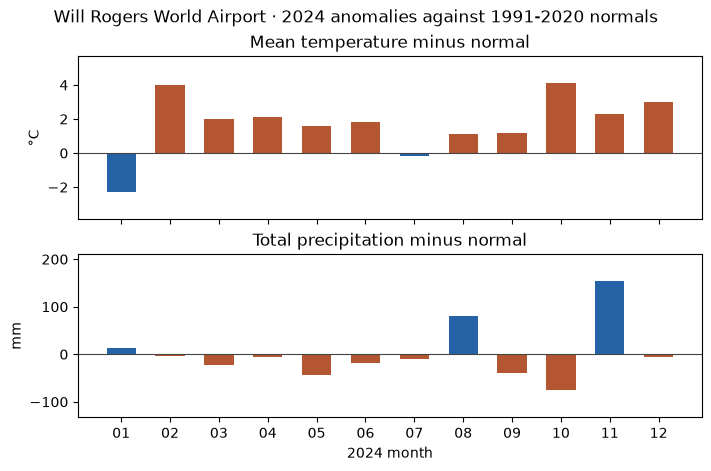

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

months = frame.index.str.slice(5, 7)
fig, axes = plt.subplots(2, 1, figsize=(7, 4.6), layout="constrained", sharex=True)
for ax, column, title, unit, (above, below) in zip(
    axes,
    ["TAVG anomaly", "PRCP anomaly"],
    ["Mean temperature minus normal", "Total precipitation minus normal"],
    ["°C", "mm"],
    [("#b45631", "#2563a6"), ("#2563a6", "#b45631")],
    strict=True,
):
    values = frame[column]
    ax.bar(
        months,
        values,
        width=0.6,
        color=[above if value >= 0 else below for value in values],
    )
    ax.axhline(0, color="#444444", linewidth=0.8)
    ax.set(title=title, ylabel=unit)
    ax.margins(y=0.25)
axes[-1].set_xlabel("2024 month")
fig.suptitle("Will Rogers World Airport · 2024 anomalies against 1991-2020 normals")
plt.show()

## 4. Verify, and handle a stale lockfile

Verification is offline: it checks the manifest and cached bytes against the
lockfile. A repeat pull then restores both pinned assets from that lockfile and
the cache.

Neither source is a stable filename. Both are query-shaped URLs that the
agencies revise: NCEI revises GSOM as late station reports arrive, and the
1991-2020 normals files are corrected occasionally even though their period is
fixed. The same URL can return different bytes months later. Restoration then
exits 4, reports every asset whose bytes changed, and rewrites nothing. Accept
the new bytes for the named entries with
`usdata pull dataset.yaml --update noaa:gsom`, or with
`pull(manifest, update=["noaa:gsom"])` in Python; see
[`--update` in the manifest reference](https://docs.usdata.dev/reference/manifests/#pull-refresh-and-restore).
This notebook does not simulate that drift.

Keep the manifest, the lockfile, and the cached bytes together in your own
analysis repository. A checksum detects a revision but cannot recreate bytes
upstream no longer serves. The SDK checkout ignores generated example
lockfiles.

In [7]:
drift = verify(manifest)
assert not drift, drift
again = pull(manifest)
print(f"Verification passed: {not drift}")
print(f"Restored from lockfile: {again.from_lockfile}")
print(f"All assets came from cache: {all(value.from_cache for value in again.fetched)}")

Verification passed: True
Restored from lockfile: True
All assets came from cache: True
